In [2]:
# パッケージのインストール
# Ultralytics（YOLOv8）のインストール
!pip install ultralytics

# その他必要なパッケージのインストール
!pip install opencv-python matplotlib pandas

# GPU の確認
!python -c "import torch; print(torch.cuda.is_available())"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.7 MB/s eta 0:00:00
True


Saving img1.jpg to img1 (2).jpg
['.config', '.ipynb_checkpoints', 'img1 (1).jpg', 'img1.jpg', 'img1 (2).jpg', 'sample_data']


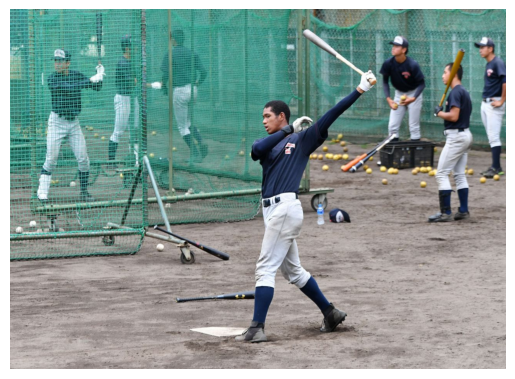

In [7]:
# 画像ファイルのアップロード
from google.colab import files
uploaded = files.upload()  # ファイル選択ダイアログが表示される

# アップロードされたファイルを確認
import os
print(os.listdir("/content/"))


# アップロードされた画像ファイル名 (例: 'img1.jpg' を使用)
image_filename = 'img1.jpg'

# 画像を読み込んで表示
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread(image_filename)
plt.imshow(img)
plt.axis('off') # 軸を非表示にする
plt.show()

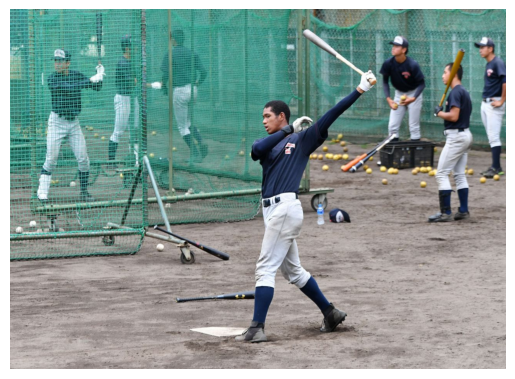

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# アップロードされた画像ファイル名
image_filename = 'img1.jpg'

# 画像を読み込んで表示
img = mpimg.imread(image_filename)
plt.imshow(img)
plt.axis('off') # 軸を非表示にする
plt.show()

In [8]:
# 推論スクリプトの作成と実行
from ultralytics import YOLO
import cv2

# --- 設定 ---
IMAGE_PATH = "/content/img1.jpg"  # アップロードした画像のパス
MODEL_NAME = "yolov8n-pose"       # 使用モデル（初回は自動ダウンロード）

# --- モデルの読み込み ---
model = YOLO(f"{MODEL_NAME}.pt")

# --- 推論の実行 ---
results = model(IMAGE_PATH)

print("推論完了！")





Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/img1.jpg: 480x640 7 persons, 77.8ms
Speed: 9.5ms preprocess, 77.8ms inference, 40.1ms postprocess per image at shape (1, 3, 480, 640)
推論完了！


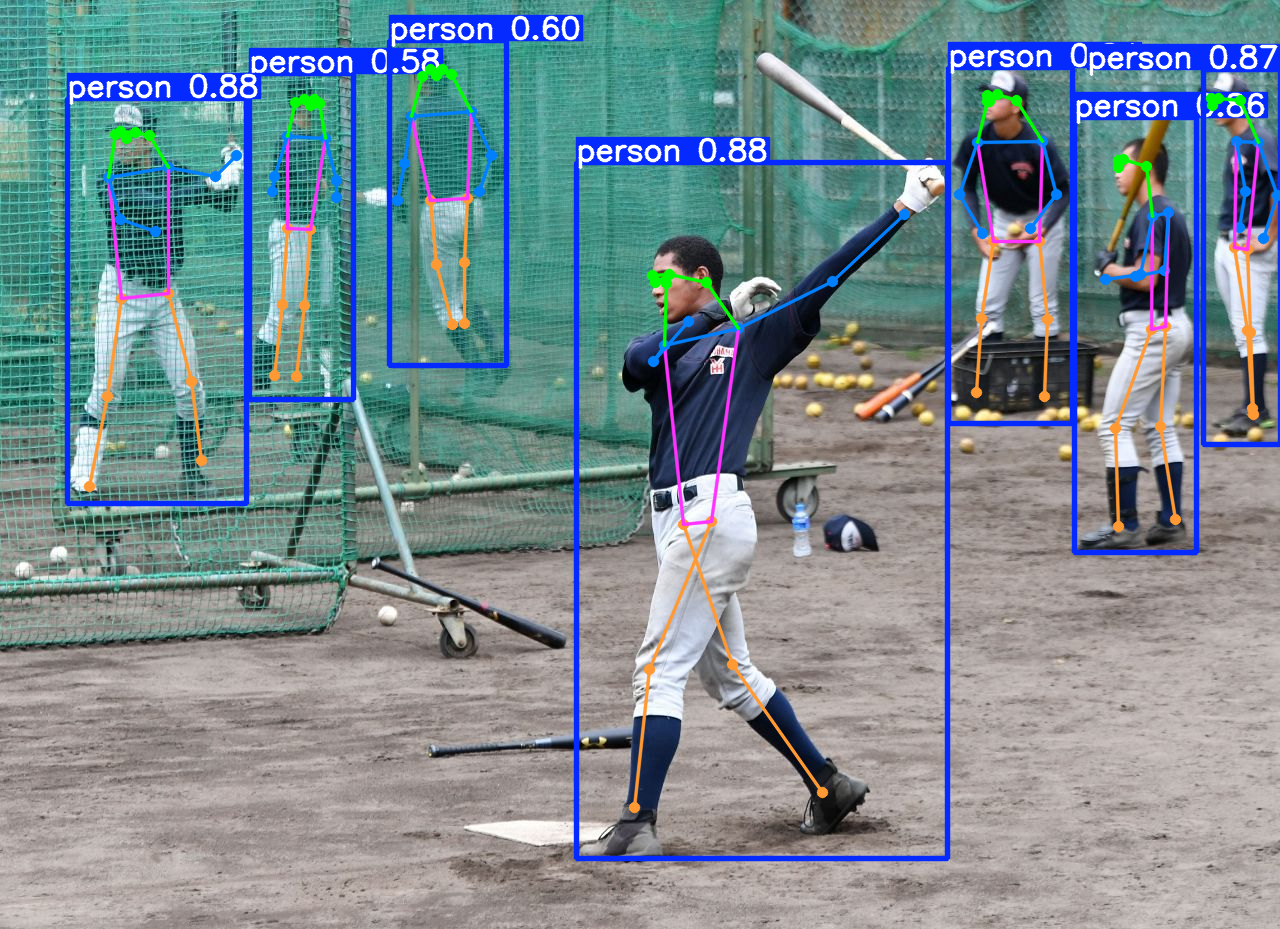

In [9]:
#
from google.colab.patches import cv2_imshow

for result in results:
    img_with_keypoints = result.plot()  # キーポイントを描画した画像
    cv2_imshow(img_with_keypoints)      # Colab用表示


In [11]:

# 骨格情報を保存

import pandas as pd

KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle"
]

OUTPUT_CSV = "/content/keypoints.csv"
all_rows = []  # 全人物分をまとめるリスト

for result in results:
    if result.keypoints is None:
        print("キーポイントが検出されませんでした")
        continue

    kps_np = result.keypoints.data.cpu().numpy()

    for person_idx, person_kps in enumerate(kps_np):
        for i, name in enumerate(KEYPOINT_NAMES):
            x, y, conf = person_kps[i]
            all_rows.append({
                "person_id": person_idx,
                "keypoint": name,
                "x": round(float(x), 2),
                "y": round(float(y), 2),
                "confidence": round(float(conf), 4)
            })

df = pd.DataFrame(all_rows)
df.to_csv(OUTPUT_CSV, index=False)  # ループの外で1回だけ保存
print(f"CSVを保存しました: {OUTPUT_CSV}")
print(df.to_string(index=False))


CSVを保存しました: /content/keypoints.csv
 person_id       keypoint       x      y  confidence
         0           nose  655.04 282.60      0.9660
         0       left_eye  669.77 274.26      0.9527
         0      right_eye  652.38 275.71      0.7464
         0       left_ear  706.75 282.14      0.9295
         0      right_ear  666.54 283.38      0.2863
         0  left_shoulder  738.89 328.14      0.9989
         0 right_shoulder  664.67 345.05      0.9821
         0     left_elbow  832.39 281.71      0.9948
         0    right_elbow  653.54 361.87      0.8561
         0     left_wrist  904.40 214.68      0.9761
         0    right_wrist  688.52 321.15      0.7603
         0       left_hip  711.85 521.53      0.9993
         0      right_hip  683.74 524.99      0.9972
         0      left_knee  649.08 669.07      0.9979
         0     right_knee  732.73 664.78      0.9933
         0     left_ankle  634.25 807.21      0.9809
         0    right_ankle  822.38 792.31      0.9611
         1 


image 1/1 /content/img1.jpg: 480x640 6 persons, 5 sports balls, 6 baseball bats, 6.9ms
Speed: 3.0ms preprocess, 6.9ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
推論完了！


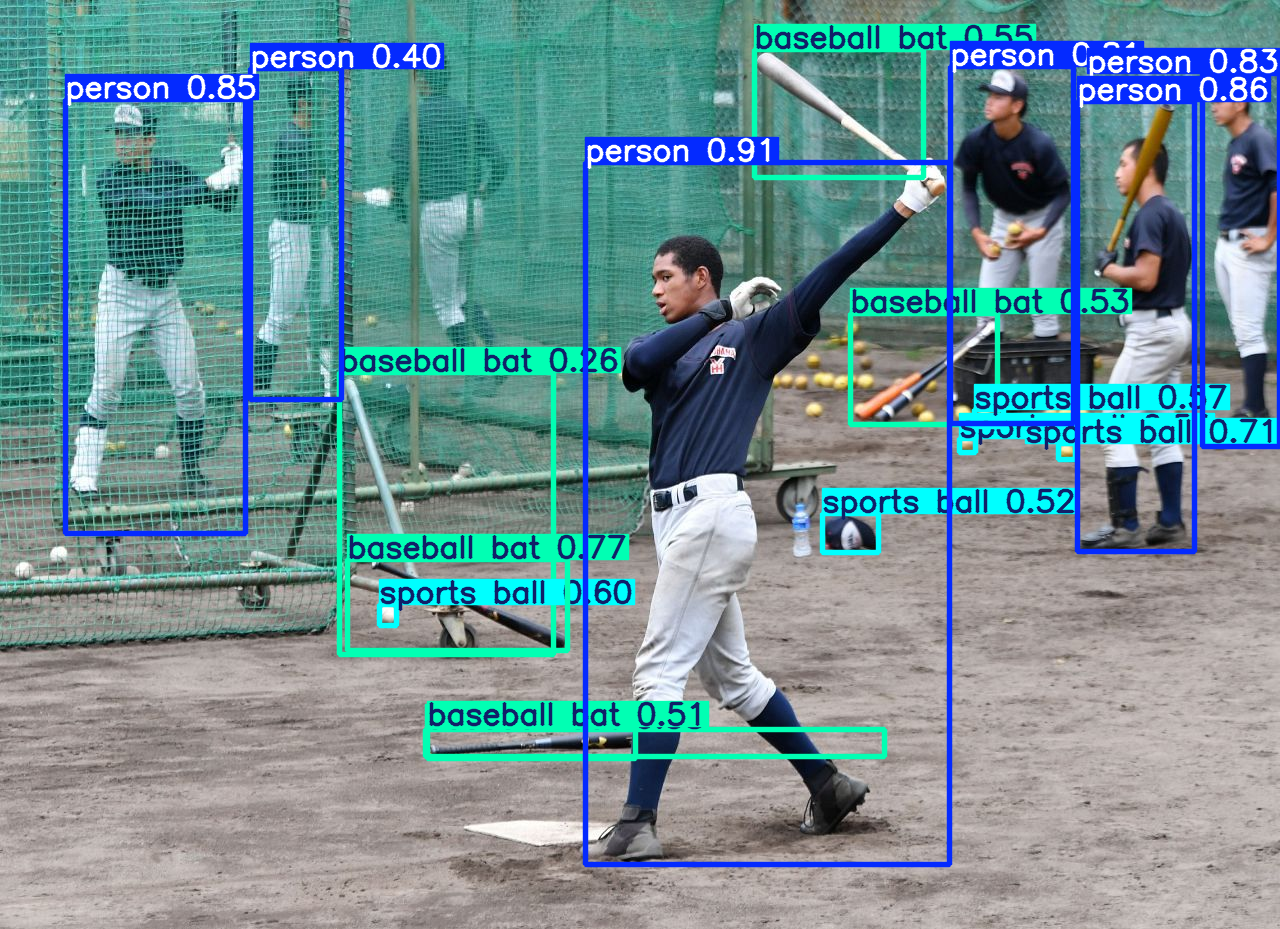

CSVを保存しました: /content/bat_boxes.csv
       class     x1     y1     x2     y2  confidence
baseball bat 347.70 559.46 567.08 650.90      0.7730
baseball bat 754.21  49.83 923.49 177.99      0.5519
baseball bat 850.28 313.53 997.52 424.89      0.5274
baseball bat 427.15 726.89 635.43 758.28      0.5129
baseball bat 425.61 729.21 884.01 756.26      0.3819
baseball bat 339.44 372.00 553.45 654.07      0.2569


In [15]:

# バットを物体認識

from ultralytics import YOLO

IMAGE_PATH = "/content/img1.jpg"
MODEL_NAME = "yolov8n"  # 物体検出モデル

model = YOLO(f"{MODEL_NAME}.pt")
results = model(IMAGE_PATH)

print("推論完了！")

# 検出結果の画像表示
from google.colab.patches import cv2_imshow

for result in results:
    img_with_boxes = result.plot()  # バウンディングボックスを描画
    cv2_imshow(img_with_boxes)

# 検出結果を csv ファイルとして保存
import pandas as pd

OUTPUT_CSV = "/content/bat_boxes.csv"
BAT_CLASS_ID = 34  # baseball bat の COCOクラス番号

all_rows = []

for result in results:
    boxes = result.boxes
    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i].item())
        if cls_id != BAT_CLASS_ID:
            continue  # バット以外はスキップ
        x1, y1, x2, y2 = boxes.xyxy[i].tolist()
        conf = float(boxes.conf[i].item())
        all_rows.append({
            "class": "baseball bat",
            "x1": round(x1, 2),
            "y1": round(y1, 2),
            "x2": round(x2, 2),
            "y2": round(y2, 2),
            "confidence": round(conf, 4)
        })

if all_rows:
    df = pd.DataFrame(all_rows)
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"CSVを保存しました: {OUTPUT_CSV}")
    print(df.to_string(index=False))
else:
    print("バットが検出されませんでした。モデルサイズを大きくして再試行してください。")



In [17]:
# 打者の自動推定

import pandas as pd

# CSVを読み込む
kp_df = pd.read_csv("/content/keypoints.csv")
bat_df = pd.read_csv("/content/bat_boxes.csv")

print("=== keypoints.csv ===")
print(kp_df.head())
print(f"\n人物数: {kp_df['person_id'].nunique()} 人")

print("\n=== bat_boxes.csv ===")
print(bat_df)

# 手首のみ抽出（left_wrist / right_wrist）
wrist_df = kp_df[kp_df["keypoint"].isin(["left_wrist", "right_wrist"])].copy()

print("手首キーポイント一覧：")
print(wrist_df.to_string(index=False))



=== keypoints.csv ===
   person_id   keypoint       x       y  confidence
0          0       nose  655.04  282.60      0.9660
1          0   left_eye  669.77  274.26      0.9527
2          0  right_eye  652.38  275.71      0.7464
3          0   left_ear  706.75  282.14      0.9295
4          0  right_ear  666.54  283.38      0.2863

人物数: 7 人

=== bat_boxes.csv ===
          class      x1      y1      x2      y2  confidence
0  baseball bat  347.70  559.46  567.08  650.90      0.7730
1  baseball bat  754.21   49.83  923.49  177.99      0.5519
2  baseball bat  850.28  313.53  997.52  424.89      0.5274
3  baseball bat  427.15  726.89  635.43  758.28      0.5129
4  baseball bat  425.61  729.21  884.01  756.26      0.3819
5  baseball bat  339.44  372.00  553.45  654.07      0.2569
手首キーポイント一覧：
 person_id    keypoint       x      y  confidence
         0  left_wrist  904.40 214.68      0.9761
         0 right_wrist  688.52 321.15      0.7603
         1  left_wrist  236.20 155.02      0.9057
 

In [20]:
import numpy as np

def point_to_box_distance(px, py, x1, y1, x2, y2):
    """点 (px, py) と矩形 (x1, y1, x2, y2) の最短距離を計算する"""
    dx = max(x1 - px, 0, px - x2)
    dy = max(y1 - py, 0, py - y2)
    return np.sqrt(dx**2 + dy**2)

# 各人物の最小距離を記録
person_ids = wrist_df["person_id"].unique()
results = []

for pid in person_ids:
    person_wrists = wrist_df[wrist_df["person_id"] == pid]
    min_dist = float("inf")

    for _, wrist in person_wrists.iterrows():
        wx, wy = wrist["x"], wrist["y"]
        for _, bat in bat_df.iterrows():
            dist = point_to_box_distance(wx, wy, bat["x1"], bat["y1"], bat["x2"], bat["y2"])
            if dist < min_dist:
                min_dist = dist

    results.append({"person_id": pid, "min_distance_to_bat": round(min_dist, 2)})

dist_df = pd.DataFrame(results).sort_values("min_distance_to_bat")
print(dist_df.to_string(index=False))

# 打者の特定
batter_id = dist_df.iloc[0]["person_id"]
batter_dist = dist_df.iloc[0]["min_distance_to_bat"]

print(f"打者と判定された人物: person_id = {int(batter_id)}")
print(f"バットとの最短距離: {batter_dist} px")


 person_id  min_distance_to_bat
         0                36.69
         4                80.02
         3               113.51
         5               171.70
         6               174.61
         1               231.43
         2               256.87
打者と判定された人物: person_id = 0
バットとの最短距離: 36.69 px


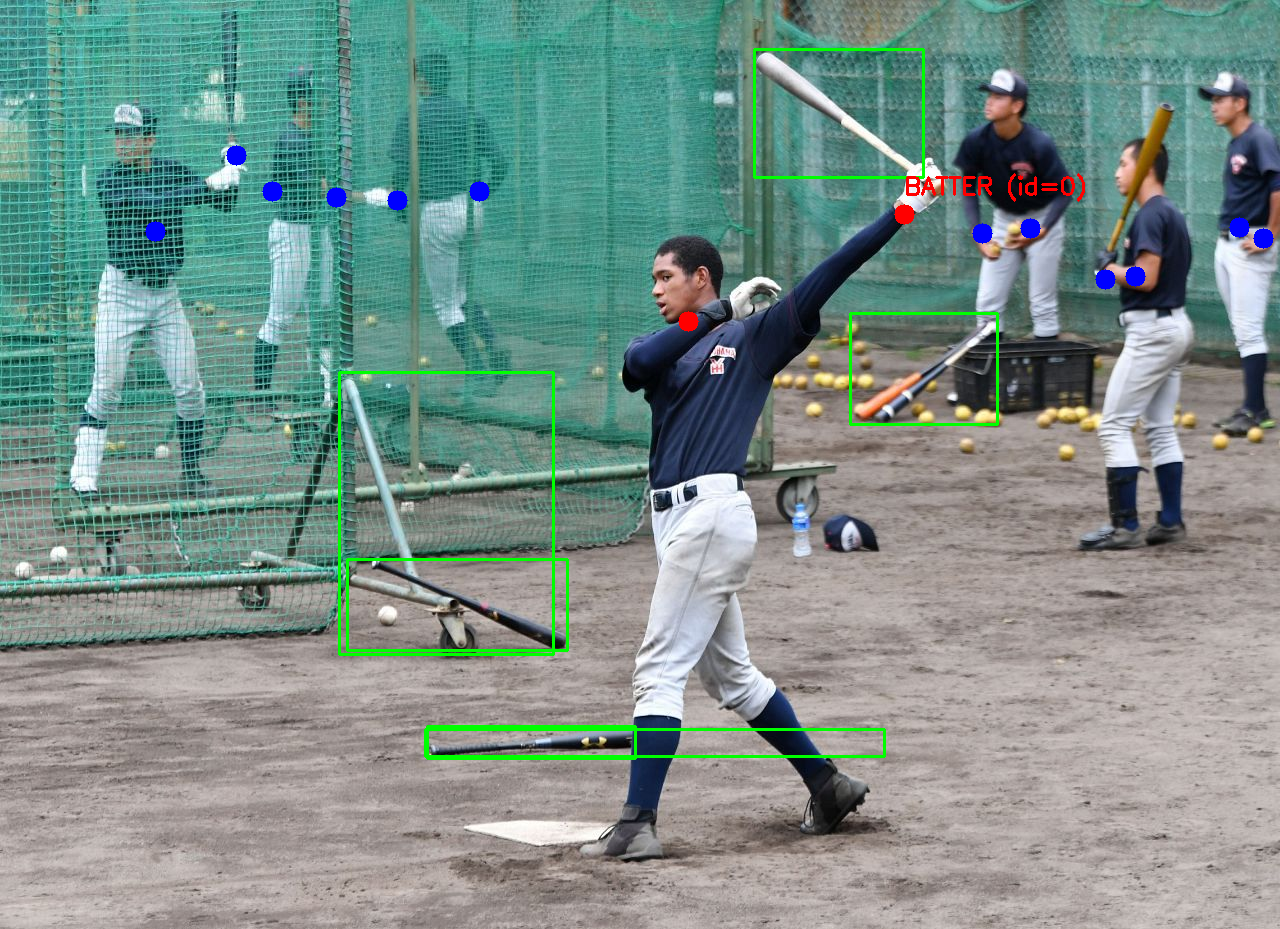

In [21]:
# 結果を描画

import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/img1.jpg")

# 全人物の手首を描画（青）
for _, row in wrist_df.iterrows():
    color = (0, 0, 255) if row["person_id"] == batter_id else (255, 0, 0)
    cv2.circle(img, (int(row["x"]), int(row["y"])), 10, color, -1)

# バットのバウンディングボックスを描画（緑）
for _, bat in bat_df.iterrows():
    cv2.rectangle(img, (int(bat["x1"]), int(bat["y1"])), (int(bat["x2"]), int(bat["y2"])), (0, 255, 0), 2)

# 打者ラベルを描画
batter_wrists = wrist_df[wrist_df["person_id"] == batter_id]
if not batter_wrists.empty:
    lx = int(batter_wrists.iloc[0]["x"])
    ly = int(batter_wrists.iloc[0]["y"]) - 20
    cv2.putText(img, f"BATTER (id={int(batter_id)})", (lx, ly),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

cv2_imshow(img)
